In [21]:
import os
import cv2
import numpy as np
import pandas as pd

from tqdm import tqdm

In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    if "landmarks.csv" in files:
        print(os.path.join(root, "landmarks.csv"))

/content/drive/MyDrive/AI_Personal_Stylist/datasets/landmarks.csv


In [24]:
landmarks = pd.read_csv(
    "/content/drive/MyDrive/AI_Personal_Stylist/datasets/landmarks.csv"
)

print(landmarks.shape)

landmarks.head()

(3345, 133)


,image_name,x_0,y_0,z_0,v_0,x_1,y_1,z_1,v_1,x_2,...,z_30,v_30,x_31,y_31,z_31,v_31,x_32,y_32,z_32,v_32
0,000242.jpg,0.528114,0.394190,-0.385114,0.999902,0.551572,0.380946,-0.349805,0.999841,0.562067,...,-0.597790,0.885452,0.340820,0.837020,-0.464781,0.881047,0.781626,0.860475,-0.732348,0.916506
1,127774.jpg,0.562119,0.258463,-1.073987,0.999801,0.601826,0.235643,-1.017335,0.999352,0.621495,...,0.283673,0.038120,0.604510,1.331599,0.801270,0.011623,0.428979,1.307187,0.014324,0.023548
2,059415.jpg,0.631948,0.357898,-0.693593,0.999971,0.642627,0.339306,-0.669784,0.999931,0.651986,...,0.428700,0.110689,0.686511,1.069409,0.030404,0.132786,0.631896,1.054492,0.240767,0.128118
3,080655.jpg,0.472713,0.108839,-0.398280,0.999920,0.486893,0.090239,-0.358356,0.999811,0.496536,...,0.070961,0.353042,0.606845,0.952268,0.051820,0.748885,0.554261,0.964541,-0.179616,0.818753
4,091255.jpg,0.328489,0.194002,-0.643718,0.999739,0.334360,0.149552,-0.604800,0.998997,0.350069,...,-0.039389,0.004257,0.730577,1.622418,0.058257,0.001938,0.616331,1.635101,-0.230562,0.002015


In [25]:
LANDMARKS = {
    "NOSE": 0,

    "LEFT_SHOULDER": 11,
    "RIGHT_SHOULDER": 12,

    "LEFT_ELBOW": 13,
    "RIGHT_ELBOW": 14,

    "LEFT_WRIST": 15,
    "RIGHT_WRIST": 16,

    "LEFT_HIP": 23,
    "RIGHT_HIP": 24,

    "LEFT_KNEE": 25,
    "RIGHT_KNEE": 26,

    "LEFT_ANKLE": 27,
    "RIGHT_ANKLE": 28
}

In [26]:
def distance3d(row, p1, p2):
    x1, y1, z1 = row[f"x_{p1}"], row[f"y_{p1}"], row[f"z_{p1}"]
    x2, y2, z2 = row[f"x_{p2}"], row[f"y_{p2}"], row[f"z_{p2}"]

    return np.sqrt(
        (x2 - x1) ** 2 +
        (y2 - y1) ** 2 +
        (z2 - z1) ** 2
    )

In [27]:
def midpoint3d(row, p1, p2):

    return np.array([
        (row[f"x_{p1}"] + row[f"x_{p2}"]) / 2,
        (row[f"y_{p1}"] + row[f"y_{p2}"]) / 2,
        (row[f"z_{p1}"] + row[f"z_{p2}"]) / 2
    ])

In [28]:
def point_distance(a, b):
    return np.linalg.norm(a - b)

In [29]:
def estimated_height(row):

    shoulder_mid = midpoint3d(row, 11, 12)
    hip_mid = midpoint3d(row, 23, 24)
    knee_mid = midpoint3d(row, 25, 26)
    ankle_mid = midpoint3d(row, 27, 28)

    head = np.array([
        row["x_0"],
        row["y_0"],
        row["z_0"]
    ])

    return (
        point_distance(head, shoulder_mid)
        + point_distance(shoulder_mid, hip_mid)
        + point_distance(hip_mid, knee_mid)
        + point_distance(knee_mid, ankle_mid)
    )

In [30]:
def angle3d(row, a, b, c):

    A = np.array([
        row[f"x_{a}"],
        row[f"y_{a}"],
        row[f"z_{a}"]
    ])

    B = np.array([
        row[f"x_{b}"],
        row[f"y_{b}"],
        row[f"z_{b}"]
    ])

    C = np.array([
        row[f"x_{c}"],
        row[f"y_{c}"],
        row[f"z_{c}"]
    ])

    BA = A - B
    BC = C - B

    cosine = np.dot(BA, BC) / (
        np.linalg.norm(BA) *
        np.linalg.norm(BC)
    )

    cosine = np.clip(cosine, -1, 1)

    return np.degrees(np.arccos(cosine))

In [31]:
def normalize(value, height):

    if height == 0:
        return 0

    return value / height

In [32]:
features = []

for _, row in tqdm(landmarks.iterrows(), total=len(landmarks)):

    # ==================================================
    # Height
    # ==================================================
    height = estimated_height(row)

    if height <= 0:
        continue

    # ==================================================
    # Body Widths
    # ==================================================
    shoulder_width = distance3d(row, 11, 12)
    hip_width = distance3d(row, 23, 24)

    # ==================================================
    # Midpoints
    # ==================================================
    shoulder_mid = midpoint3d(row, 11, 12)
    hip_mid = midpoint3d(row, 23, 24)

    torso_length = point_distance(
        shoulder_mid,
        hip_mid
    )

    # ==================================================
    # Arms
    # ==================================================
    left_upper_arm = distance3d(row, 11, 13)
    right_upper_arm = distance3d(row, 12, 14)

    left_forearm = distance3d(row, 13, 15)
    right_forearm = distance3d(row, 14, 16)

    left_arm = left_upper_arm + left_forearm
    right_arm = right_upper_arm + right_forearm

    avg_arm = (left_arm + right_arm) / 2

    # ==================================================
    # Legs
    # ==================================================
    left_thigh = distance3d(row, 23, 25)
    right_thigh = distance3d(row, 24, 26)

    left_calf = distance3d(row, 25, 27)
    right_calf = distance3d(row, 26, 28)

    left_leg = left_thigh + left_calf
    right_leg = right_thigh + right_calf

    avg_leg = (left_leg + right_leg) / 2

    # ==================================================
    # Ratios
    # ==================================================
    shoulder_hip_ratio = shoulder_width / hip_width if hip_width else 0

    torso_leg_ratio = torso_length / avg_leg if avg_leg else 0

    shoulder_height_ratio = shoulder_width / height

    hip_height_ratio = hip_width / height

    torso_height_ratio = torso_length / height

    arm_height_ratio = avg_arm / height

    leg_height_ratio = avg_leg / height

    arm_leg_ratio = avg_arm / avg_leg if avg_leg else 0

    shoulder_arm_ratio = shoulder_width / avg_arm if avg_arm else 0

    hip_leg_ratio = hip_width / avg_leg if avg_leg else 0

    left_right_arm_ratio = left_arm / right_arm if right_arm else 0

    left_right_leg_ratio = left_leg / right_leg if right_leg else 0

    # ==================================================
    # Symmetry
    # ==================================================
    arm_symmetry = abs(left_arm - right_arm)

    leg_symmetry = abs(left_leg - right_leg)

    shoulder_level_diff = abs(
        row["y_11"] - row["y_12"]
    )

    hip_level_diff = abs(
        row["y_23"] - row["y_24"]
    )

    knee_level_diff = abs(
        row["y_25"] - row["y_26"]
    )

    ankle_level_diff = abs(
        row["y_27"] - row["y_28"]
    )

    # ==================================================
    # Angles
    # ==================================================
    left_elbow_angle = angle3d(row,11,13,15)

    right_elbow_angle = angle3d(row,12,14,16)

    left_knee_angle = angle3d(row,23,25,27)

    right_knee_angle = angle3d(row,24,26,28)

    # ==================================================
    # Visibility
    # ==================================================
    visibility = [
        row[f"v_{i}"]
        for i in range(33)
    ]

    avg_visibility = np.mean(visibility)

    min_visibility = np.min(visibility)

    max_visibility = np.max(visibility)

    visible_landmarks = sum(
        v > 0.5 for v in visibility
    )

    pose_score = avg_visibility * visible_landmarks

    # ==================================================
    # Feature Dictionary
    # ==================================================
    features.append({

        "image_name": row["image_name"],

        "height": height,

        "shoulder_width": normalize(shoulder_width,height),
        "hip_width": normalize(hip_width,height),
        "torso_length": normalize(torso_length,height),

        "left_upper_arm": normalize(left_upper_arm,height),
        "right_upper_arm": normalize(right_upper_arm,height),

        "left_forearm": normalize(left_forearm,height),
        "right_forearm": normalize(right_forearm,height),

        "left_arm": normalize(left_arm,height),
        "right_arm": normalize(right_arm,height),

        "left_thigh": normalize(left_thigh,height),
        "right_thigh": normalize(right_thigh,height),

        "left_calf": normalize(left_calf,height),
        "right_calf": normalize(right_calf,height),

        "left_leg": normalize(left_leg,height),
        "right_leg": normalize(right_leg,height),

        "shoulder_hip_ratio": shoulder_hip_ratio,
        "torso_leg_ratio": torso_leg_ratio,

        "shoulder_height_ratio": shoulder_height_ratio,
        "hip_height_ratio": hip_height_ratio,
        "torso_height_ratio": torso_height_ratio,

        "arm_height_ratio": arm_height_ratio,
        "leg_height_ratio": leg_height_ratio,

        "arm_leg_ratio": arm_leg_ratio,

        "shoulder_arm_ratio": shoulder_arm_ratio,
        "hip_leg_ratio": hip_leg_ratio,

        "left_right_arm_ratio": left_right_arm_ratio,
        "left_right_leg_ratio": left_right_leg_ratio,

        "arm_symmetry": arm_symmetry,
        "leg_symmetry": leg_symmetry,

        "shoulder_level_diff": shoulder_level_diff,
        "hip_level_diff": hip_level_diff,
        "knee_level_diff": knee_level_diff,
        "ankle_level_diff": ankle_level_diff,

        "left_elbow_angle": left_elbow_angle,
        "right_elbow_angle": right_elbow_angle,

        "left_knee_angle": left_knee_angle,
        "right_knee_angle": right_knee_angle,

        "avg_visibility": avg_visibility,
        "min_visibility": min_visibility,
        "max_visibility": max_visibility,

        "visible_landmarks": visible_landmarks,
        "pose_score": pose_score
    })

100%|██████████| 3345/3345 [00:02<00:00, 1579.85it/s]


In [33]:
def classify_body_shape(row):

    shoulder = row["shoulder_width"]
    hip = row["hip_width"]

    ratio = shoulder / (hip + 1e-6)

    if ratio < 0.90:
        shape = "Pear"
        confidence = 1 - ratio

    elif ratio > 1.10:
        shape = "Inverted Triangle"
        confidence = ratio - 1

    else:
        shape = "Rectangle"
        confidence = 0.85

    confidence = min(max(confidence, 0.70), 0.95)

    return pd.Series([shape, round(confidence,2)])

In [34]:
features_df = pd.DataFrame(features)

print(features_df.shape)

features_df.head()

(3345, 44)


,image_name,height,shoulder_width,hip_width,torso_length,left_upper_arm,right_upper_arm,left_forearm,right_forearm,left_arm,...,ankle_level_diff,left_elbow_angle,right_elbow_angle,left_knee_angle,right_knee_angle,avg_visibility,min_visibility,max_visibility,visible_landmarks,pose_score
0,000242.jpg,1.393440,0.180116,0.113132,0.214008,0.246414,0.178688,0.196012,0.148303,0.442426,...,0.034890,111.864601,165.399237,42.105360,58.863758,0.913915,0.588983,0.999981,33,30.159183
1,127774.jpg,2.279049,0.169809,0.091758,0.226928,0.118676,0.186199,0.203284,0.335108,0.321960,...,0.005337,99.512729,133.024645,120.302406,55.474718,0.733967,0.008661,0.999921,24,17.615212
2,059415.jpg,1.356195,0.247312,0.161482,0.253328,0.114053,0.103921,0.200337,0.210656,0.314390,...,0.002076,143.951009,94.668817,91.836779,118.467153,0.792293,0.063710,0.999986,26,20.599629
3,080655.jpg,1.095705,0.234089,0.148595,0.253520,0.153331,0.126855,0.195257,0.168428,0.348589,...,0.020122,93.797343,135.914880,146.316695,145.391566,0.906545,0.314443,0.999983,31,28.102885
4,091255.jpg,1.841356,0.178051,0.114710,0.298462,0.209987,0.145568,0.361725,0.176533,0.571712,...,0.034984,120.901119,115.332242,134.072952,126.142977,0.743571,0.001938,0.999903,25,18.589267


In [35]:
# Predict body shape

features_df[["body_shape","confidence"]] = features_df.apply(
    classify_body_shape,
    axis=1
)

features_df[["image_name","body_shape","confidence"]].head()

,image_name,body_shape,confidence
0,000242.jpg,Inverted Triangle,0.70
1,127774.jpg,Inverted Triangle,0.85
2,059415.jpg,Inverted Triangle,0.70
3,080655.jpg,Inverted Triangle,0.70
4,091255.jpg,Inverted Triangle,0.70


In [36]:
features_df["body_shape"].value_counts()

,count
body_shape,
Inverted Triangle,3322
Rectangle,18
Pear,5


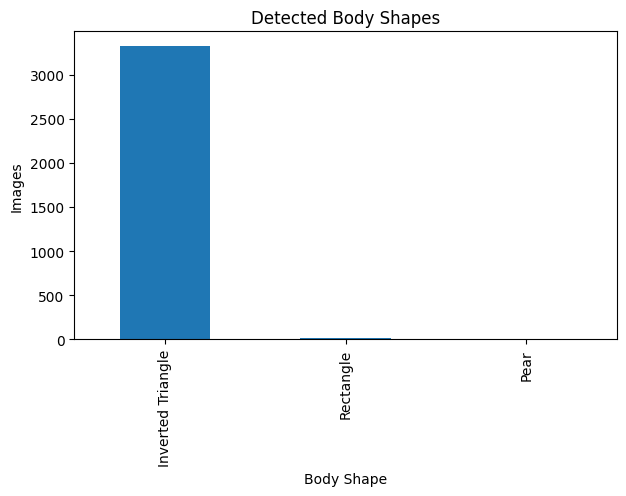

In [37]:
import matplotlib.pyplot as plt

features_df["body_shape"].value_counts().plot(
    kind="bar",
    figsize=(7,4)
)

plt.title("Detected Body Shapes")
plt.xlabel("Body Shape")
plt.ylabel("Images")
plt.show()

In [38]:
features_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3345 entries, 0 to 3344
Data columns (total 46 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   image_name             3345 non-null   object 
 1   height                 3345 non-null   float64
 2   shoulder_width         3345 non-null   float64
 3   hip_width              3345 non-null   float64
 4   torso_length           3345 non-null   float64
 5   left_upper_arm         3345 non-null   float64
 6   right_upper_arm        3345 non-null   float64
 7   left_forearm           3345 non-null   float64
 8   right_forearm          3345 non-null   float64
 9   left_arm               3345 non-null   float64
 10  right_arm              3345 non-null   float64
 11  left_thigh             3345 non-null   float64
 12  right_thigh            3345 non-null   float64
 13  left_calf              3345 non-null   float64
 14  right_calf             3345 non-null   float64
 15  left

In [39]:
features_df.isnull().sum().sum()

np.int64(0)

In [40]:
features_df.describe().T

,count,mean,std,min,25%,50%,75%,max
height,3345.0,1.555504,0.907167,0.174219,1.015171,1.287714,1.773756,10.082782
shoulder_width,3345.0,0.245083,0.114796,0.020630,0.173695,0.211394,0.273795,0.938381
hip_width,3345.0,0.149230,0.080613,0.025867,0.097819,0.122908,0.170665,0.585726
torso_length,3345.0,0.271504,0.052731,0.130214,0.236397,0.267433,0.300783,0.667479
left_upper_arm,3345.0,0.164838,0.050143,0.017006,0.130676,0.157388,0.191378,0.600073
right_upper_arm,3345.0,0.166892,0.057878,0.046646,0.127534,0.154758,0.195359,0.648990
left_forearm,3345.0,0.203603,0.088485,0.031279,0.137112,0.178904,0.265698,0.585318
right_forearm,3345.0,0.214556,0.092632,0.018686,0.148293,0.188590,0.271722,0.607693
left_arm,3345.0,0.368441,0.121615,0.099818,0.280655,0.336203,0.451068,1.161417
right_arm,3345.0,0.381448,0.134167,0.070773,0.288622,0.343972,0.454564,1.214588


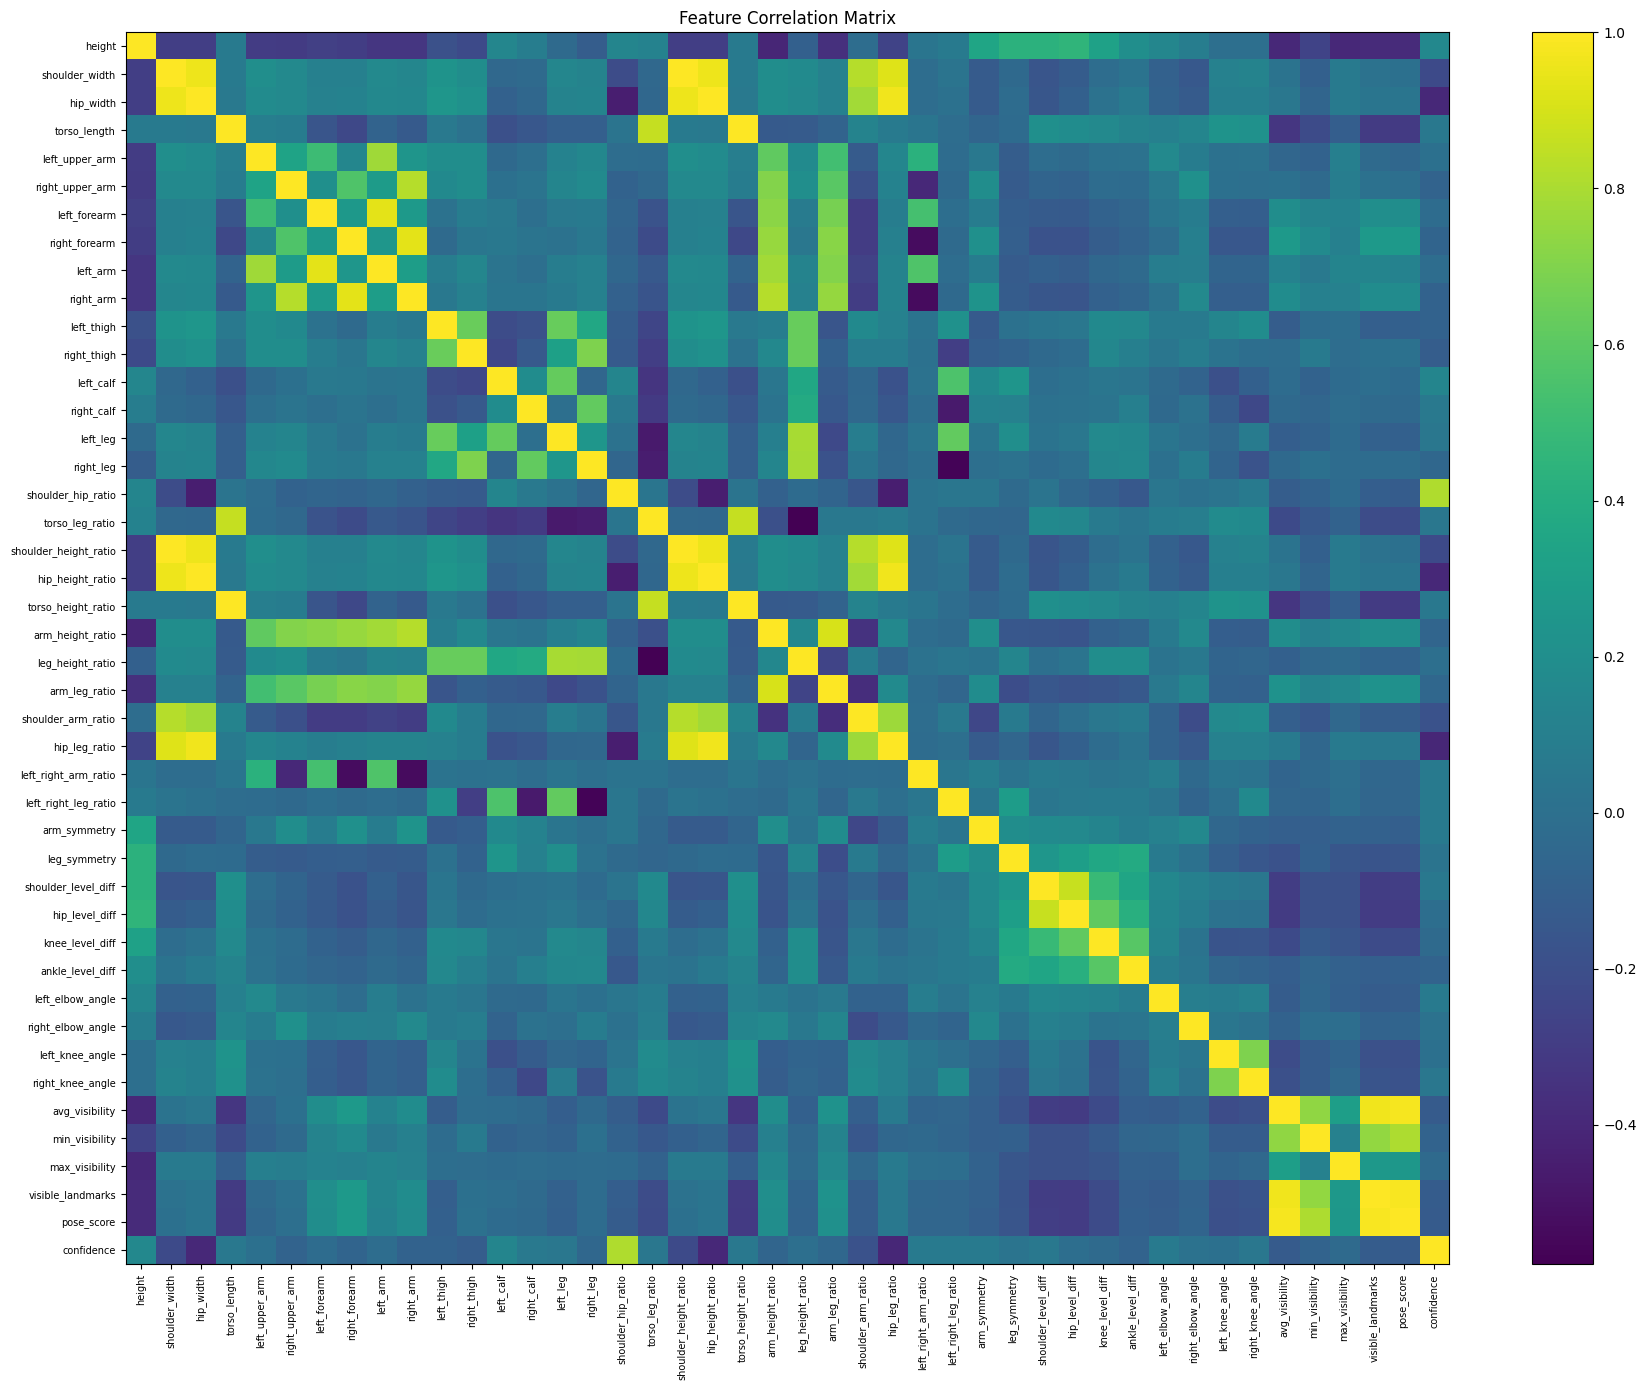

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# Keep only numeric columns
numeric_df = features_df.select_dtypes(include=[np.number])

corr = numeric_df.corr()

plt.figure(figsize=(18,14))
plt.imshow(corr, aspect="auto")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90, fontsize=7)
plt.yticks(range(len(corr.columns)), corr.columns, fontsize=7)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [43]:
print("Duplicate Rows:", features_df.duplicated().sum())

Duplicate Rows: 0


In [44]:
output_path = "/content/drive/MyDrive/AI_Personal_Stylist/datasets/features.csv"

features_df.to_csv(output_path, index=False)

print("Saved to:", output_path)

Saved to: /content/drive/MyDrive/AI_Personal_Stylist/datasets/features.csv
